# 02 — Exploratory Data Analysis

Customer population, revenue distribution, churn patterns, cohort retention, and concentration — computed against the point-in-time cutoff in `docs/target_definition.md`. Every number here is real output from this run, not illustrative.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data import config
from features.rfm import compute_rfm

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')

cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
horizon_end = cutoff + pd.Timedelta(days=config.CHURN_HORIZON_DAYS)
lookback_start = cutoff - pd.Timedelta(days=config.ACTIVE_LOOKBACK_DAYS)
qualifying = orders[orders['status'] == 'completed']

## Population & activity

In [2]:
active_ids = set(qualifying[(qualifying['order_date'] > lookback_start) & (qualifying['order_date'] <= cutoff)]['customer_id'])
print(f'total customers: {len(customers):,}')
print(f'active at cutoff (order in last {config.ACTIVE_LOOKBACK_DAYS}d): {len(active_ids):,} ({len(active_ids)/len(customers):.1%})')

total customers: 8,000
active at cutoff (order in last 180d): 5,097 (63.7%)


## Revenue distribution (historical, as of cutoff)

count    7477.000000
mean      757.693488
std       768.175314
min         3.630000
25%       206.040000
50%       511.880000
75%      1054.390000
max      6204.700000
Name: amount, dtype: float64
skew: 1.91


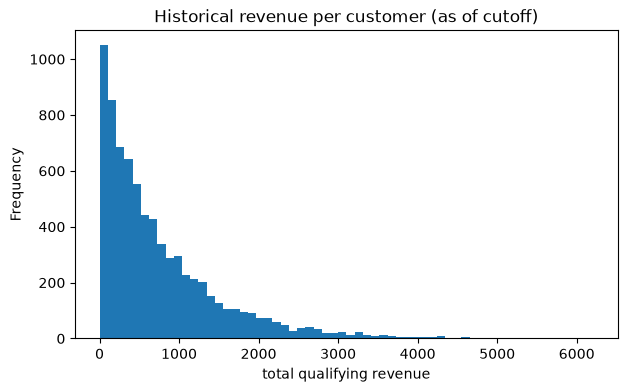

In [3]:
hist = qualifying[qualifying['order_date'] <= cutoff]
rev_by_cust = hist.groupby('customer_id')['amount'].sum()
print(rev_by_cust.describe())
print('skew:', round(rev_by_cust.skew(), 2))
fig, ax = plt.subplots(figsize=(7, 4))
rev_by_cust.plot(kind='hist', bins=60, ax=ax)
ax.set_title('Historical revenue per customer (as of cutoff)')
ax.set_xlabel('total qualifying revenue')
plt.show()

## Customer concentration (Pareto)

In [4]:
sorted_rev = rev_by_cust.sort_values(ascending=False)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
for pct in [0.1, 0.2, 0.5]:
    n = int(len(sorted_rev) * pct)
    print(f'top {int(pct*100)}% of customers -> {cum_share.iloc[n-1]:.1%} of historical revenue')

top 10% of customers -> 33.5% of historical revenue
top 20% of customers -> 52.8% of historical revenue
top 50% of customers -> 85.2% of historical revenue


## RFM distributions

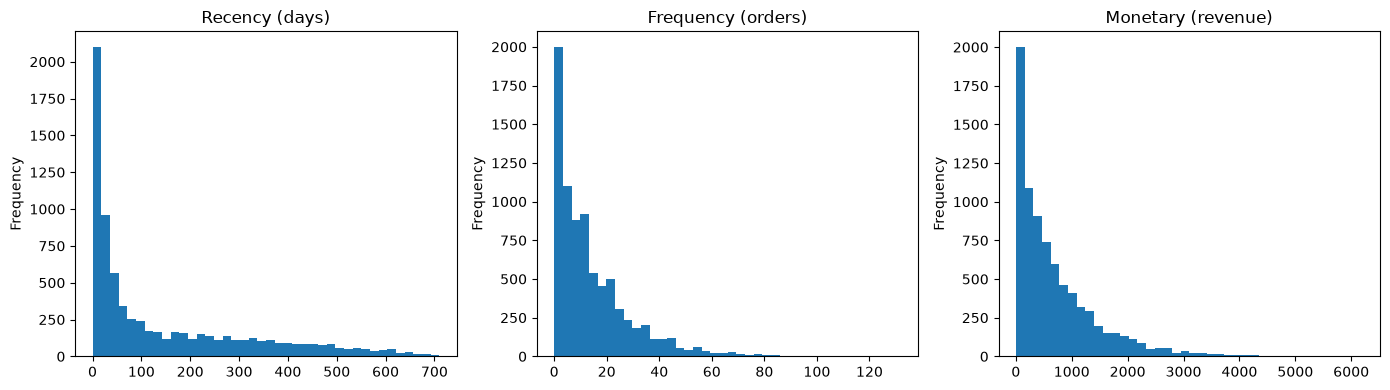

,recency_days,frequency,monetary
count,7477.000000,8000.000000,8000.000000
mean,146.222950,14.347625,708.159276
std,172.203258,15.003039,765.894011
min,0.000000,0.000000,0.000000
25%,14.000000,3.750000,155.017500
50%,59.000000,10.000000,465.725000
75%,244.000000,20.000000,1004.275000
max,710.000000,132.000000,6204.700000


In [5]:
rfm = compute_rfm(orders, customers, as_of=cutoff)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rfm['recency_days'].dropna().plot(kind='hist', bins=40, ax=axes[0], title='Recency (days)')
rfm['frequency'].plot(kind='hist', bins=40, ax=axes[1], title='Frequency (orders)')
rfm['monetary'].plot(kind='hist', bins=40, ax=axes[2], title='Monetary (revenue)')
plt.tight_layout()
plt.show()
rfm[['recency_days', 'frequency', 'monetary']].describe()

## Tenure and average order value

In [6]:
tenure_days = (cutoff - customers['signup_date']).dt.days
print('tenure days:\n', tenure_days.describe())
print('\noverall AOV (historical):', round(hist['amount'].sum() / len(hist), 2))

tenure days:
 count    8000.000000
mean      489.526000
std       171.861016
min         4.000000
25%       368.000000
50%       520.000000
75%       635.000000
max       730.000000
Name: signup_date, dtype: float64

overall AOV (historical): 49.36


## Churn rate and breakdowns

Churn = no completed order in the 90-day horizon after cutoff, among customers active in the 180 days before cutoff (see `docs/target_definition.md`).

In [7]:
future_ids = set(qualifying[(qualifying['order_date'] > cutoff) & (qualifying['order_date'] <= horizon_end)]['customer_id'])
active_cust = customers[customers['customer_id'].isin(active_ids)].copy()
active_cust['churned'] = ~active_cust['customer_id'].isin(future_ids)
print(f"overall churn rate: {active_cust['churned'].mean():.1%} (n={len(active_cust):,})")
print('\nby acquisition channel:')
print((active_cust.groupby('acquisition_channel')['churned'].mean() * 100).round(1).sort_values(ascending=False))
print('\nby plan:')
print((active_cust.groupby('plan')['churned'].mean() * 100).round(1).sort_values(ascending=False))

overall churn rate: 28.6% (n=5,097)

by acquisition channel:
acquisition_channel
affiliate      32.7
social         32.7
organic        29.5
email          27.7
paid_search    25.6
referral       23.5
Name: churned, dtype: float64

by plan:
plan
bronze    44.8
silver    22.1
gold       9.7
Name: churned, dtype: float64


**Caveat on `plan`**: in this synthetic generator, `plan` is assigned from the same latent activity-rate variable that also drives the churn hazard (see `src/data/generator.py`), so the huge gap above (bronze ~45% vs gold ~10%) is partly a construction artifact, not an independently discovered business insight — treat it as a sanity check that the simulation is internally consistent, not as a real finding to replicate on real data.

## Does engagement trend predict churn?

A naive support-ticket-count split does **not** separate churners from non-churners in this run (ticket rate and lifetime length offset each other in the generator — a genuine negative finding, left in rather than hidden). A recent-vs-historical order-rate ratio does.

In [8]:
support_hist = support[support['created_at'] <= cutoff]
ticket_counts = support_hist.groupby('customer_id').size().rename('ticket_count')
active_cust = active_cust.merge(ticket_counts, left_on='customer_id', right_index=True, how='left')
active_cust['ticket_count'] = active_cust['ticket_count'].fillna(0)
corr_tickets = active_cust['ticket_count'].corr(active_cust['churned'].astype(int))
print('corr(ticket_count, churned):', round(corr_tickets, 3), '(negligible)')

recent_start = cutoff - pd.Timedelta(days=30)
older_start = cutoff - pd.Timedelta(days=180)
recent = qualifying[(qualifying['order_date'] > recent_start) & (qualifying['order_date'] <= cutoff)]
prior = qualifying[(qualifying['order_date'] > older_start) & (qualifying['order_date'] <= recent_start)]
recent_30d = recent.groupby('customer_id').size().rename('recent_30d')
prior_150d = prior.groupby('customer_id').size().rename('prior_150d')
active_cust = active_cust.merge(recent_30d, left_on='customer_id', right_index=True, how='left')
active_cust = active_cust.merge(prior_150d, left_on='customer_id', right_index=True, how='left')
active_cust[['recent_30d', 'prior_150d']] = active_cust[['recent_30d', 'prior_150d']].fillna(0)
active_cust['engagement_ratio'] = active_cust['recent_30d'] / (active_cust['prior_150d'] / 5 + 0.1)
corr_eng = active_cust['engagement_ratio'].corr(active_cust['churned'].astype(int))
print('corr(engagement_ratio, churned):', round(corr_eng, 3))
print(active_cust.groupby(pd.qcut(active_cust['engagement_ratio'], 4, duplicates='drop'))['churned'].mean().round(3))

corr(ticket_count, churned): -0.011 (negligible)
corr(engagement_ratio, churned): -0.131
engagement_ratio
(-0.001, 0.526]    0.447
(0.526, 1.429]     0.105
(1.429, 50.0]      0.129
Name: churned, dtype: float64


**Takeaway**: raw activity counts (like a ticket tally) aren't automatically predictive — the *trend* (recent activity relative to the customer's own baseline) is what carries signal here. This is the argument for building trend/ratio features explicitly in Phase 4 rather than only feeding raw counts into a model.

## Cohort retention (signup month)

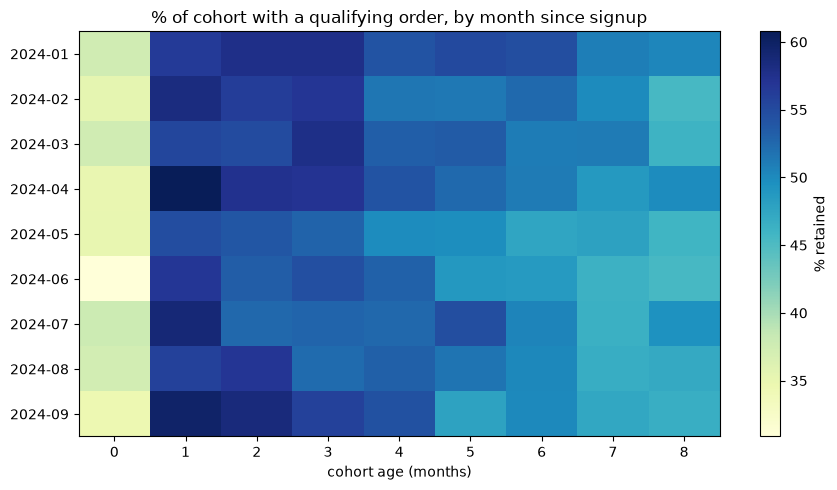

cohort_age,0,1,2,3,4,5,6,7,8
cohort_month,,,,,,,,,
2024-01,37.4,56.4,57.7,57.7,54.1,55.1,54.6,50.9,50.3
2024-02,35.3,58.2,56.2,56.8,51.5,51.3,52.4,49.9,45.4
2024-03,37.4,55.4,54.9,57.8,53.3,53.4,51.0,51.1,46.1
2024-04,35.0,60.8,57.4,57.0,54.2,52.5,51.1,48.7,49.9
2024-05,35.1,54.7,54.0,52.9,49.9,49.7,47.5,47.9,45.8
2024-06,30.9,56.8,53.4,54.6,53.0,48.8,48.6,46.2,45.4
2024-07,37.8,58.8,52.6,52.8,52.6,54.6,50.4,46.4,49.4
2024-08,37.2,55.8,56.8,52.3,53.1,51.7,50.2,46.7,47.1
2024-09,34.6,59.7,58.5,55.8,54.4,47.7,50.1,47.3,46.5


In [9]:
cust2 = customers.copy()
cust2['cohort_month'] = cust2['signup_date'].dt.to_period('M')
orders2 = qualifying.merge(cust2[['customer_id', 'cohort_month']], on='customer_id')
orders2['order_month'] = orders2['order_date'].dt.to_period('M')
orders2['cohort_age'] = (orders2['order_month'] - orders2['cohort_month']).apply(lambda x: x.n)
cohort_sizes = cust2.groupby('cohort_month').size()
retention = orders2.groupby(['cohort_month', 'cohort_age'])['customer_id'].nunique().unstack(fill_value=0)
retention_pct = retention.divide(cohort_sizes, axis=0) * 100
display_cohorts = retention_pct.iloc[:9, :9]
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(display_cohorts, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(display_cohorts.shape[1]))
ax.set_yticks(range(display_cohorts.shape[0]))
ax.set_yticklabels([str(p) for p in display_cohorts.index])
ax.set_xlabel('cohort age (months)')
ax.set_title('% of cohort with a qualifying order, by month since signup')
fig.colorbar(im, ax=ax, label='% retained')
plt.tight_layout()
plt.show()
display_cohorts.round(1)

## Outliers

C:\Users\trilo\AppData\Local\Temp\ipykernel_27216\1653963164.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(rev_by_cust, vert=True)


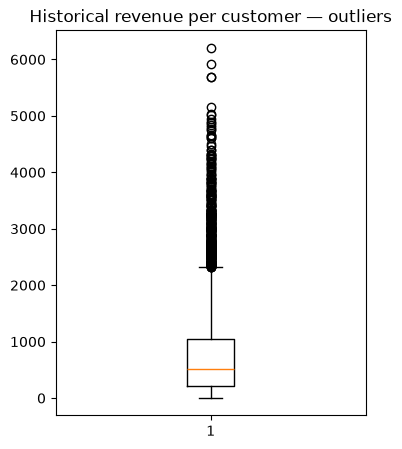

IQR outlier threshold: 2326.91; customers above it: 355 (4.7%)


In [10]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(rev_by_cust, vert=True)
ax.set_title('Historical revenue per customer — outliers')
plt.show()
q1, q3 = rev_by_cust.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f'IQR outlier threshold: {upper:.2f}; customers above it: {(rev_by_cust > upper).sum()} ({(rev_by_cust > upper).mean():.1%})')